# 02 — Classical NLP Module

**Subject:** NLP — Topic 1 (Isaac González)  
**Goal:** Build classical text classifiers using TF-IDF representations.

## Pipeline
1. Preprocess tweet captions (clean → tokenise → remove stopwords → stem)
2. Vectorise with **TF-IDF** (unigrams + bigrams, 10k features)
3. Train **Multinomial Naive Bayes** — fast probabilistic baseline
4. Train **Logistic Regression** — stronger discriminative model
5. Optimise both with **Grid Search** (5-fold cross-validation)
6. Save probabilities for the late fusion module

## Expected results
| Model | F1-macro |
|---|---|
| Naive Bayes | ~0.58 |
| Logistic Regression | ~0.61 |

Both models outperform the random baseline (0.33) confirming that
text carries meaningful emotional signal.

## Cell 1 — Setup and dataset loading

In [1]:
import os
os.chdir("/Users/yesicarb/Desktop/UIE/3º Curso/2 SEM/PROYECTO/emotion/multimodal_emotion")

import pandas as pd
import sys
sys.path.append("src")

from nlp_classic.classifier import run_nlp_classic

df = pd.read_csv("data/processed/labels.csv")
print(f"Dataset loaded: {df.shape}")
print(df['label'].value_counts())

Dataset loaded: (4869, 4)
label
neutral     1921
positive    1731
negative    1217
Name: count, dtype: int64


## Cell 2 — Baseline: Naive Bayes + Logistic Regression

This runs the full pipeline from `src/nlp_classic/classifier.py`:
preprocessing → TF-IDF → NB + LR → evaluation → save JSON.

⏱️ **Expected time: ~1 minute**

In [2]:
nb, lr, vec, y_test = run_nlp_classic(df)

Preprocessing texts...

=== Naive Bayes ===
              precision    recall  f1-score   support

    negative       0.57      0.45      0.50       244
     neutral       0.60      0.61      0.61       384
    positive       0.59      0.66      0.62       346

    accuracy                           0.59       974
   macro avg       0.59      0.57      0.58       974
weighted avg       0.59      0.59      0.59       974


=== Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.64      0.42      0.51       244
     neutral       0.60      0.72      0.65       384
    positive       0.65      0.67      0.66       346

    accuracy                           0.63       974
   macro avg       0.63      0.60      0.61       974
weighted avg       0.63      0.63      0.62       974


Results saved to results/metrics_nlp_classic.json


## Cell 3 — Results visualisation

Compare both classifiers against the random baseline.

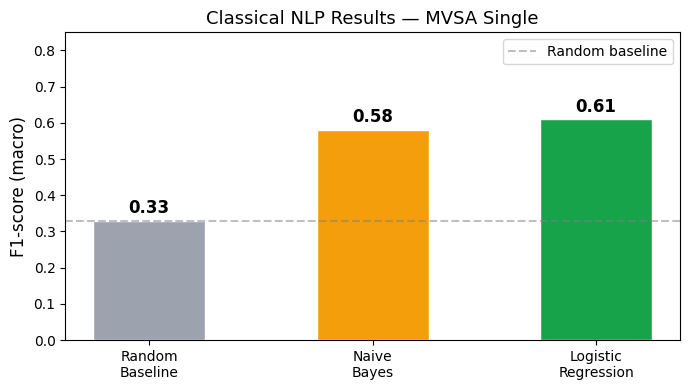

Figure saved to results/figures/nlp_classic_results.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np

modules   = ['Random\nBaseline', 'Naive\nBayes', 'Logistic\nRegression']
f1_scores = [0.33, 0.58, 0.61]
colors    = ['#9ca3af', '#f59e0b', '#16a34a']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(modules, f1_scores, color=colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.2f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.set_ylim(0, 0.85)
ax.set_ylabel('F1-score (macro)', fontsize=12)
ax.set_title('Classical NLP Results — MVSA Single', fontsize=13)
ax.axhline(y=0.33, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/nlp_classic_results.png', dpi=150)
plt.show()
print("Figure saved to results/figures/nlp_classic_results.png")

## Cell 4 — Grid Search: Logistic Regression

We search over the following parameters:
- `max_features`: vocabulary size [5000, 10000, 20000]
- `ngram_range`: unigrams only vs unigrams+bigrams
- `sublinear_tf`: log normalisation of term frequency
- `C`: regularisation strength [0.1, 0.5, 1.0, 5.0, 10.0]

⏱️ **Expected time: 5–10 minutes** (450 fits with 5-fold CV)

In [4]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
import sys
sys.path.append("src")
from nlp_classic.preprocessing import TextPreprocessor

# Preprocess all texts
prep   = TextPreprocessor()
texts  = [prep.preprocess(t) for t in df['text']]
labels = df['label'].tolist()

# Same split as the baseline
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels)

# Grid Search — Logistic Regression
print("Grid Search — Logistic Regression...")
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42))
])
param_grid_lr = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range':  [(1, 1), (1, 2), (1, 3)],
    'tfidf__sublinear_tf': [True, False],
    'clf__C':              [0.1, 0.5, 1.0, 5.0, 10.0],
}

gs_lr = GridSearchCV(pipe_lr, param_grid_lr,
                     cv=5, scoring='f1_macro',
                     n_jobs=-1, verbose=1)
gs_lr.fit(X_train, y_train)

print(f"\nBest parameters: {gs_lr.best_params_}")
print(f"Best F1 (CV):    {gs_lr.best_score_:.4f}")

y_pred_lr = gs_lr.predict(X_test)
print("\n=== Logistic Regression (optimised) ===")
print(classification_report(y_test, y_pred_lr))
print(f"F1 macro (test): {f1_score(y_test, y_pred_lr, average='macro'):.4f}")

Grid Search — Logistic Regression...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best parameters: {'clf__C': 5.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True}
Best F1 (CV):    0.6036

=== Logistic Regression (optimised) ===
              precision    recall  f1-score   support

    negative       0.57      0.50      0.54       244
     neutral       0.61      0.65      0.63       384
    positive       0.64      0.64      0.64       346

    accuracy                           0.61       974
   macro avg       0.61      0.60      0.60       974
weighted avg       0.61      0.61      0.61       974

F1 macro (test): 0.6017


## Cell 5 — Grid Search: Naive Bayes

⏱️ **Expected time: 3–5 minutes** (300 fits with 5-fold CV)

In [5]:
from sklearn.naive_bayes import MultinomialNB

print("Grid Search — Naive Bayes...")
pipe_nb = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   MultinomialNB())
])
param_grid_nb = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range':  [(1, 1), (1, 2)],
    'tfidf__sublinear_tf': [True, False],
    'clf__alpha':          [0.01, 0.05, 0.1, 0.5, 1.0],
}

gs_nb = GridSearchCV(pipe_nb, param_grid_nb,
                     cv=5, scoring='f1_macro',
                     n_jobs=-1, verbose=1)
gs_nb.fit(X_train, y_train)

print(f"\nBest parameters: {gs_nb.best_params_}")
print(f"Best F1 (CV):    {gs_nb.best_score_:.4f}")

y_pred_nb = gs_nb.predict(X_test)
print("\n=== Naive Bayes (optimised) ===")
print(classification_report(y_test, y_pred_nb))
print(f"F1 macro (test): {f1_score(y_test, y_pred_nb, average='macro'):.4f}")

Grid Search — Naive Bayes...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best parameters: {'clf__alpha': 0.1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True}
Best F1 (CV):    0.5786

=== Naive Bayes (optimised) ===
              precision    recall  f1-score   support

    negative       0.57      0.46      0.51       244
     neutral       0.60      0.61      0.60       384
    positive       0.60      0.67      0.63       346

    accuracy                           0.59       974
   macro avg       0.59      0.58      0.58       974
weighted avg       0.59      0.59      0.59       974

F1 macro (test): 0.5799


## Cell 6 — Save results for late fusion

We save the LR probabilities because LR outperforms NB and its
probabilities are better calibrated for fusion.
Both F1 scores are saved for the results table in the paper.

In [6]:
import json
import numpy as np

results_opt = {
    'logistic_regression': {
        'f1_macro':    f1_score(y_test, y_pred_lr, average='macro'),
        'best_params': gs_lr.best_params_,
        'report':      classification_report(y_test, y_pred_lr, output_dict=True),
        'probas':      gs_lr.predict_proba(X_test).tolist()  # used in fusion
    },
    'naive_bayes': {
        'f1_macro':    f1_score(y_test, y_pred_nb, average='macro'),
        'best_params': gs_nb.best_params_,
        'report':      classification_report(y_test, y_pred_nb, output_dict=True)
    }
}

with open('results/metrics_nlp_classic.json', 'w') as f:
    json.dump(results_opt, f, indent=2)
print("Results saved to results/metrics_nlp_classic.json")

print(f"\nFinal results:")
print(f"  Naive Bayes (optimised):          F1 = {f1_score(y_test, y_pred_nb, average='macro'):.4f}")
print(f"  Logistic Regression (optimised):  F1 = {f1_score(y_test, y_pred_lr, average='macro'):.4f}")

Results saved to results/metrics_nlp_classic.json

Final results:
  Naive Bayes (optimised):          F1 = 0.5799
  Logistic Regression (optimised):  F1 = 0.6017
